```
 ___  ___ _  _ ___ ___  ___
/ _ \|_ _| || | __| _ \/ __|
| (_) || || __ | _||   /\__ \
 \___/___|_||_|___|_|_\|___/
```
### Two connected stories from the Steam catalogue — ~83 k games, one dataset.
**Story 1 — The Engagement Ladder:** do games that reach more players cost more, rate better, and hold players longer?  
**Story 2 — Developer Power Rankings:** who dominates the review landscape, and does scale come at the cost of quality?

In [1]:
from clickhouse_driver import Client
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

CATPPUCCIN_MOCHA = [
    "#f5e0dc",  # Rosewater
    "#f2cdcd",  # Flamingo
    "#f5c2e7",  # Pink
    "#cba6f7",  # Mauve
    "#f38ba8",  # Red
    "#eba0ac",  # Maroon
    "#fab387",  # Peach
    "#f9e2af",  # Yellow
    "#a6e3a1",  # Green
    "#94e2d5",  # Teal
    "#89dceb",  # Sky
    "#74c7ec",  # Sapphire
    "#89b4fa",  # Blue
    "#b4befe",  # Lavender
]
CATPPUCCIN_BASE = "#1e1e2e"
TEXT_COLOR      = "#cdd6f4"
GRID_COLOR      = "#313244"

C_PEACH  = "#fab387"
C_GREEN  = "#a6e3a1"
C_BLUE   = "#89b4fa"
C_MAUVE  = "#cba6f7"
C_RED    = "#f38ba8"
C_TEAL   = "#94e2d5"
C_YELLOW = "#f9e2af"


def style_ax(ax):
    """Apply shared Catppuccin Mocha styling to an Axes object."""
    ax.set_facecolor(CATPPUCCIN_BASE)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=TEXT_COLOR)
    ax.xaxis.set_tick_params(labelcolor=TEXT_COLOR)
    ax.yaxis.set_tick_params(labelcolor=TEXT_COLOR)
    ax.set_axisbelow(True)

In [2]:
client = Client(
    host="localhost",
    port=9100,
    user="clickhouse",
    password="clickhouse",
    database="analytics",
)

---
## Story 1 — The Engagement Ladder
*SteamSpy groups every game into owner-count tiers (e.g. "0 – 20,000 owners", "2M – 5M owners"). If we walk up those tiers, do price, quality, and playtime all climb together — or does the ladder fall apart?*

In [3]:
rows = client.execute("""
    SELECT
        owners,
        avg(toInt32OrZero(initialprice)) / 100          AS avg_price_usd,
        avg(positive / nullIf(positive + negative, 0))  AS avg_approval,
        avg(average_forever) / 60                       AS avg_playtime_hrs,
        avg(average_2weeks) / 60                        AS avg_2w_hrs
    FROM steamspy_silver_stg_games
    FINAL
    WHERE owners IS NOT NULL AND owners != ''
    GROUP BY owners
""")


def parse_lower(tier):
    return int(tier.split(' .. ')[0].replace(',', ''))


def make_label(tier):
    lo, hi = tier.split(' .. ')

    def fmt(s):
        n = int(s.replace(',', ''))
        if n >= 1_000_000:
            return f"{n // 1_000_000}M"
        if n >= 1_000:
            return f"{n // 1_000}k"
        return str(n)

    return f"{fmt(lo)}\u2013{fmt(hi)}"


data = sorted(rows, key=lambda r: parse_lower(r[0]))

labels        = [make_label(r[0]) for r in data]
avg_prices    = [r[1] if r[1] is not None else 0 for r in data]
avg_approvals = [(r[2] * 100) if r[2] is not None else 0 for r in data]
avg_playtimes = [r[3] if r[3] is not None else 0 for r in data]
avg_2w        = [r[4] if r[4] is not None else 0 for r in data]

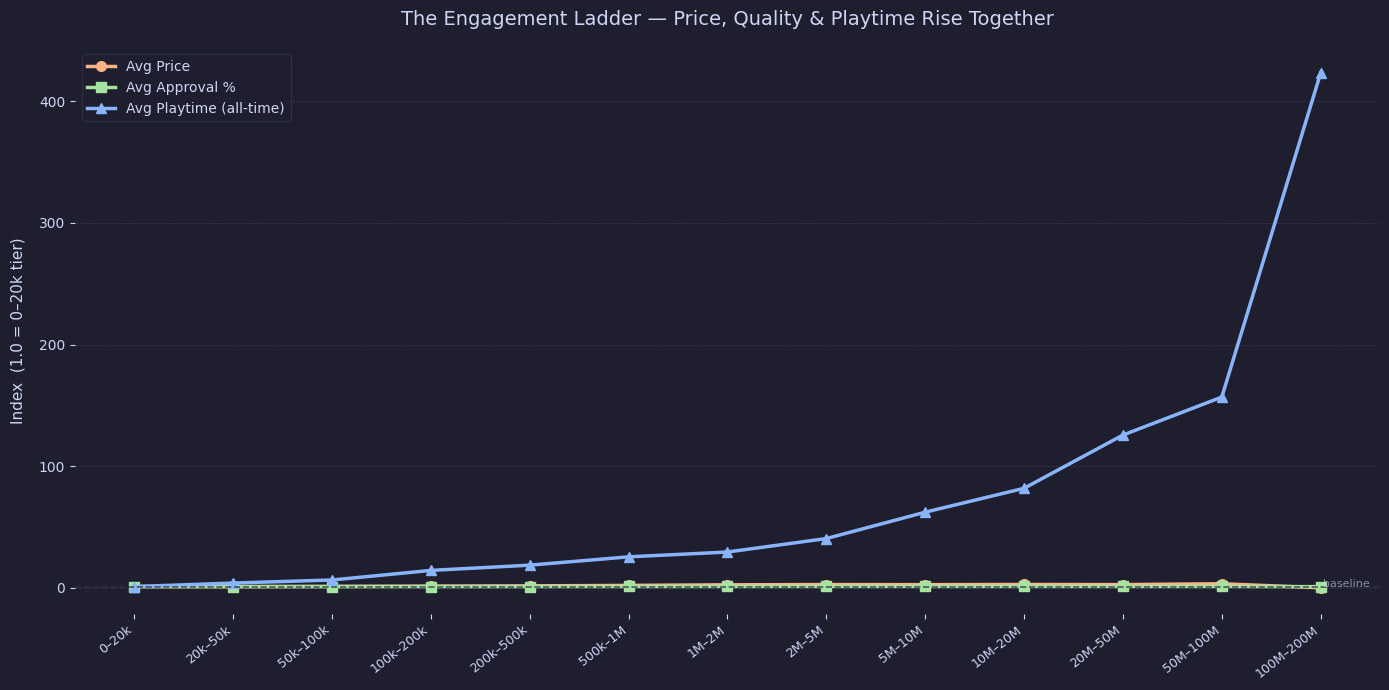

In [4]:
# Normalise every metric to 1.0 at the lowest tier (0–20k owners)
base_price    = avg_prices[0]    or 1
base_approval = avg_approvals[0] or 1
base_playtime = avg_playtimes[0] or 1

prices_idx   = [p / base_price    for p in avg_prices]
approval_idx = [a / base_approval for a in avg_approvals]
playtime_idx = [t / base_playtime for t in avg_playtimes]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(14, 7), facecolor=CATPPUCCIN_BASE)
style_ax(ax)

ax.plot(x, prices_idx,   color=C_PEACH,  linewidth=2.5, marker='o', markersize=7,
        label='Avg Price')
ax.plot(x, approval_idx, color=C_GREEN,  linewidth=2.5, marker='s', markersize=7,
        label='Avg Approval %')
ax.plot(x, playtime_idx, color=C_BLUE,   linewidth=2.5, marker='^', markersize=7,
        label='Avg Playtime (all-time)')

ax.axhline(1.0, color=GRID_COLOR, linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(len(labels) - 0.5, 1.05, 'baseline', color=TEXT_COLOR, fontsize=8, alpha=0.6, ha='right')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=38, ha='right', color=TEXT_COLOR, fontsize=9)
ax.set_ylabel('Index  (1.0 = 0\u201320k tier)', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_title('The Engagement Ladder \u2014 Price, Quality & Playtime Rise Together',
             color=TEXT_COLOR, fontsize=14, pad=16)

ax.legend(facecolor=CATPPUCCIN_BASE, labelcolor=TEXT_COLOR,
          framealpha=0.8, edgecolor=GRID_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')

plt.tight_layout()
plt.savefig('engagement_ladder.png', dpi=150, bbox_inches='tight', facecolor=CATPPUCCIN_BASE)
plt.show()

**Chart 1 — The Ladder**

Every metric is normalised so that the bottom tier (0–20k owners) = 1.0 — making relative growth legible on one axis. Three things become clear:

- **Price** (peach) rises steadily from ~\$7.66 at the bottom to ~\$25 at the 50M–100M tier, then collapses back to \$0 at 100M+ because the only games at that scale (TF2, CSGO, Dota 2) are free-to-play.
- **Approval %** (green) climbs from ~75% to ~86%, a meaningful 11-point improvement — but rises more slowly than the other metrics. Quality helps reach more players, but it is not the whole story.
- **Playtime** (blue) dwarfs the other two. Games in the 50M–100M tier are played for ~138 hours on average, a 160× multiple of the bottom tier. The ladder is steep and the rungs are mostly made of hours.

The notable anomaly: the top tier (100M–200M) breaks the price rule because those three games are free — which makes the playtime spike even more striking. People spend *more* time in free blockbusters than in any priced game on the platform.

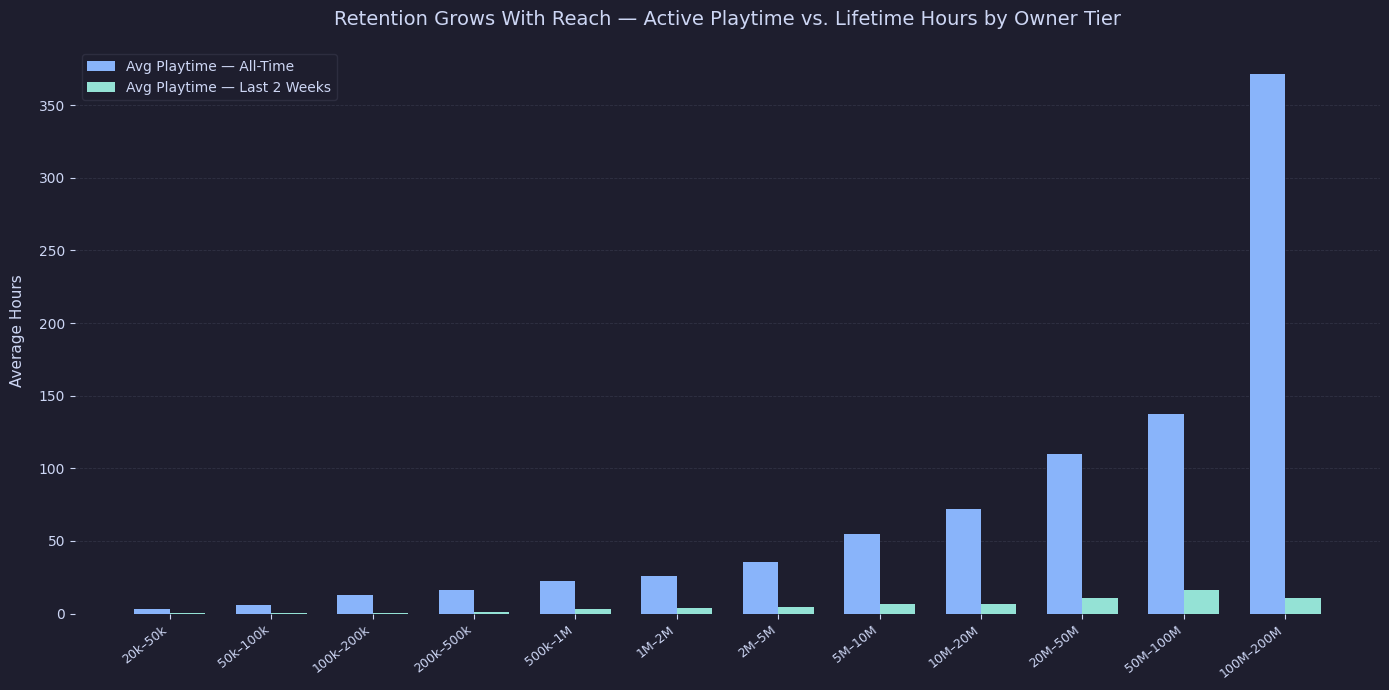

In [5]:
# Only include tiers where the 2-week average is meaningfully non-zero
valid = [
    (labels[i], avg_playtimes[i], avg_2w[i])
    for i in range(len(labels))
    if avg_2w[i] > 0.05
]
v_labels  = [v[0] for v in valid]
v_all     = [v[1] for v in valid]
v_2w      = [v[2] for v in valid]

x     = np.arange(len(v_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7), facecolor=CATPPUCCIN_BASE)
style_ax(ax)

ax.bar(x - width / 2, v_all, width, color=C_BLUE,  label='Avg Playtime \u2014 All-Time',    edgecolor='none')
ax.bar(x + width / 2, v_2w,  width, color=C_TEAL, label='Avg Playtime \u2014 Last 2 Weeks', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(v_labels, rotation=38, ha='right', color=TEXT_COLOR, fontsize=9)
ax.set_ylabel('Average Hours', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_title('Retention Grows With Reach \u2014 Active Playtime vs. Lifetime Hours by Owner Tier',
             color=TEXT_COLOR, fontsize=14, pad=16)

ax.legend(facecolor=CATPPUCCIN_BASE, labelcolor=TEXT_COLOR,
          framealpha=0.8, edgecolor=GRID_COLOR)
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')

plt.tight_layout()
plt.savefig('retention_by_tier.png', dpi=150, bbox_inches='tight', facecolor=CATPPUCCIN_BASE)
plt.show()

**Chart 2 — Retention**

Chart 1 showed that playtime *accumulates* as games reach more players. Chart 2 asks a harder question: are those hours historical, or are people still actively playing?

- The **blue bars** (all-time average) grow dramatically with each tier — we already knew this.
- The **teal bars** (2-week average) are the reveal. At the bottom tiers the 2-week bar is nearly invisible — most of those games are effectively dead. Players bought them, logged a few minutes, and never returned.
- At the 500k–1M tier the teal bar becomes visible; by 5M–10M it is reaching several hours. At 50M–100M games are averaging **16+ hours of active play in the last two weeks** — not nostalgia hours, actual current engagement.

The gap between blue and teal is a signal of *recency*: blockbuster games do not just sit on a mountain of old playtime. They keep pulling players back in, week after week.

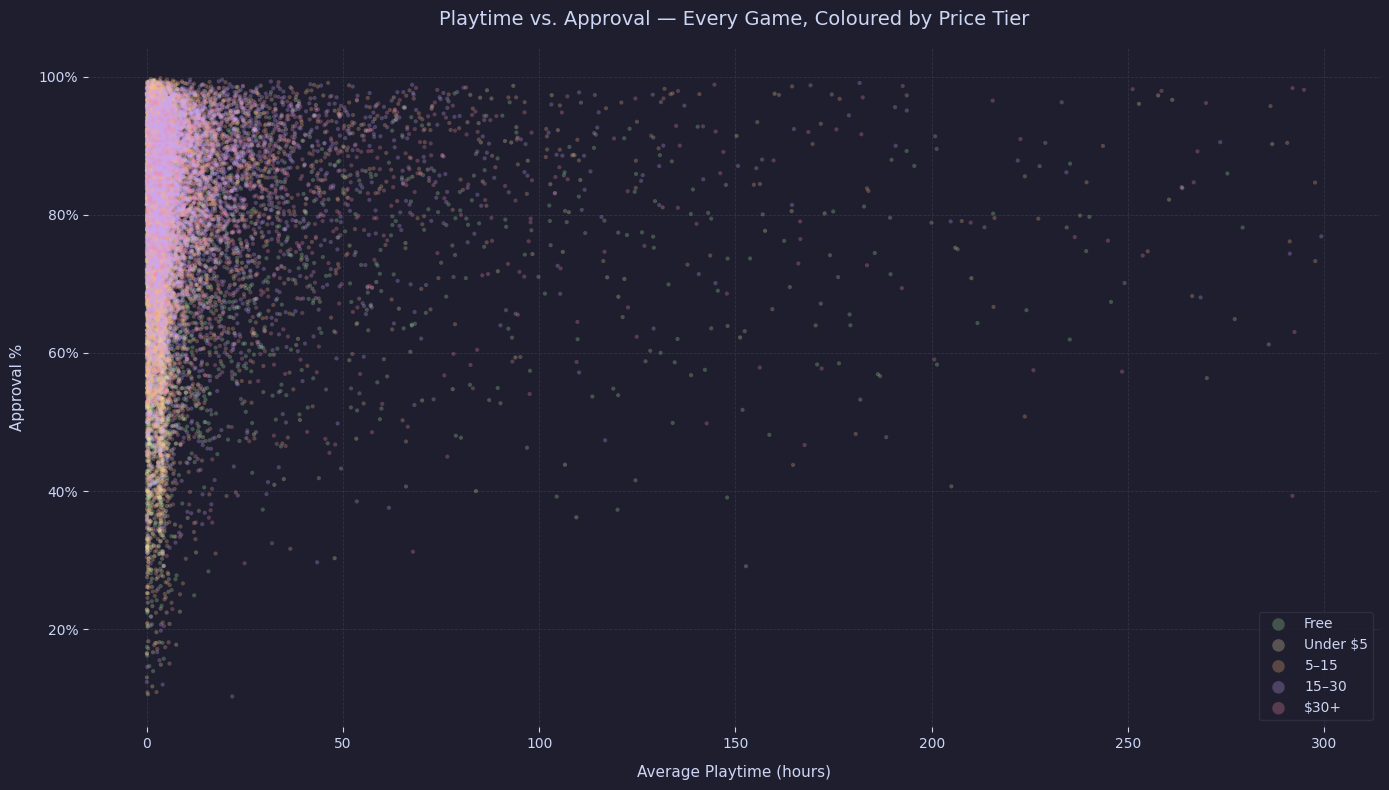

In [6]:
scatter_rows = client.execute("""
    SELECT
        average_forever / 60.0                       AS playtime_hrs,
        positive / (positive + negative)             AS approval_pct,
        toInt32OrZero(initialprice) / 100.0          AS price_usd
    FROM steamspy_silver_stg_games
    FINAL
    WHERE positive + negative > 100
      AND average_forever > 0
      AND positive > 0
      AND negative > 0
""")


def price_bucket(p):
    if p == 0:  return 'Free'
    if p < 5:   return 'Under $5'
    if p < 15:  return '$5\u2013$15'
    if p < 30:  return '$15\u2013$30'
    return '$30+'


bucket_order  = ['Free', 'Under $5', '$5\u2013$15', '$15\u2013$30', '$30+']
bucket_colors = {
    'Free':          C_GREEN,
    'Under $5':      C_YELLOW,
    '$5\u2013$15':   C_PEACH,
    '$15\u2013$30':  C_MAUVE,
    '$30+':          C_RED,
}

buckets = {k: {'x': [], 'y': []} for k in bucket_order}
for pt, appr, price in scatter_rows:
    if pt > 300 or appr is None:
        continue
    b = price_bucket(price)
    buckets[b]['x'].append(pt)
    buckets[b]['y'].append(appr * 100)

fig, ax = plt.subplots(figsize=(14, 8), facecolor=CATPPUCCIN_BASE)
style_ax(ax)

for b in bucket_order:
    ax.scatter(buckets[b]['x'], buckets[b]['y'],
               color=bucket_colors[b], alpha=0.28, s=9,
               label=b, edgecolors='none')

ax.set_xlabel('Average Playtime (hours)', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_ylabel('Approval %', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_title('Playtime vs. Approval \u2014 Every Game, Coloured by Price Tier',
             color=TEXT_COLOR, fontsize=14, pad=16)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))

ax.legend(facecolor=CATPPUCCIN_BASE, labelcolor=TEXT_COLOR,
          framealpha=0.8, edgecolor=GRID_COLOR, markerscale=3)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')

plt.tight_layout()
plt.savefig('playtime_vs_approval_scatter.png', dpi=150, bbox_inches='tight', facecolor=CATPPUCCIN_BASE)
plt.show()

**Chart 3 — The Scatter**

Charts 1 and 2 work with tier averages. This one puts every individual game on the canvas. Two things to look for:

- **The low-left mass**: the dense cloud of yellow and green points near (0–5 hrs, 40–90% approval) is the \$0.99 ocean — thousands of cheap or free games with minimal playtime and mixed reception. This is the long tail made visible.
- **The top-right drift**: as playtime climbs past 50–100 hours, the approval floor rises noticeably. Games that hold players for 100+ hours are overwhelmingly well-received (90%+ approval). This is not a guarantee — some cheap games do earn high approval — but the density shifts dramatically toward the upper-right for premium-priced titles.
- **The free outliers** (green) scatter across the full vertical range. Free-to-play is not a quality signal in either direction: beloved service games and cynical cash-grabs both live here.

Price is a filter, not a guarantee — but the $30+ cluster (red) shows the tightest concentration of long-played, well-loved games on the platform.

### Story 1 Summary — The Engagement Ladder

> *On Steam, price is a credible signal. Games that more players own cost more, earn higher approval, and generate disproportionately more playtime. Crucially, this is not just a legacy effect: blockbuster games keep their audiences actively returning week after week, while the long tail of cheap games is largely forgotten after a few minutes. The scatter confirms this is not purely a tier-level averaging artefact — at the individual game level, premium games cluster toward high playtime and high approval. The data suggests a self-reinforcing loop: quality commands a higher price, which attracts a more committed audience, which produces more hours played, which validates the price.*

---
## Story 2 — Developer Power Rankings
*A handful of studios dominate Steam's review landscape. But scale and quality are not the same thing — some studios earn massive volume with mediocre scores, while others punch far above their weight. Two charts map the territory.*

In [7]:
dev_rows = client.execute("""
    SELECT
        developer,
        count()                                           AS num_games,
        sum(positive + negative)                          AS total_reviews,
        avg(positive / nullIf(positive + negative, 0))    AS avg_approval,
        sum(positive)                                     AS total_positive,
        sum(negative)                                     AS total_negative
    FROM steamspy_silver_stg_games
    FINAL
    WHERE developer IS NOT NULL AND developer != ''
    GROUP BY developer
    HAVING num_games >= 5 AND total_reviews >= 200000
    ORDER BY total_reviews DESC
    LIMIT 20
""")


def title_case(s):
    return ' '.join(w.capitalize() for w in s.split())

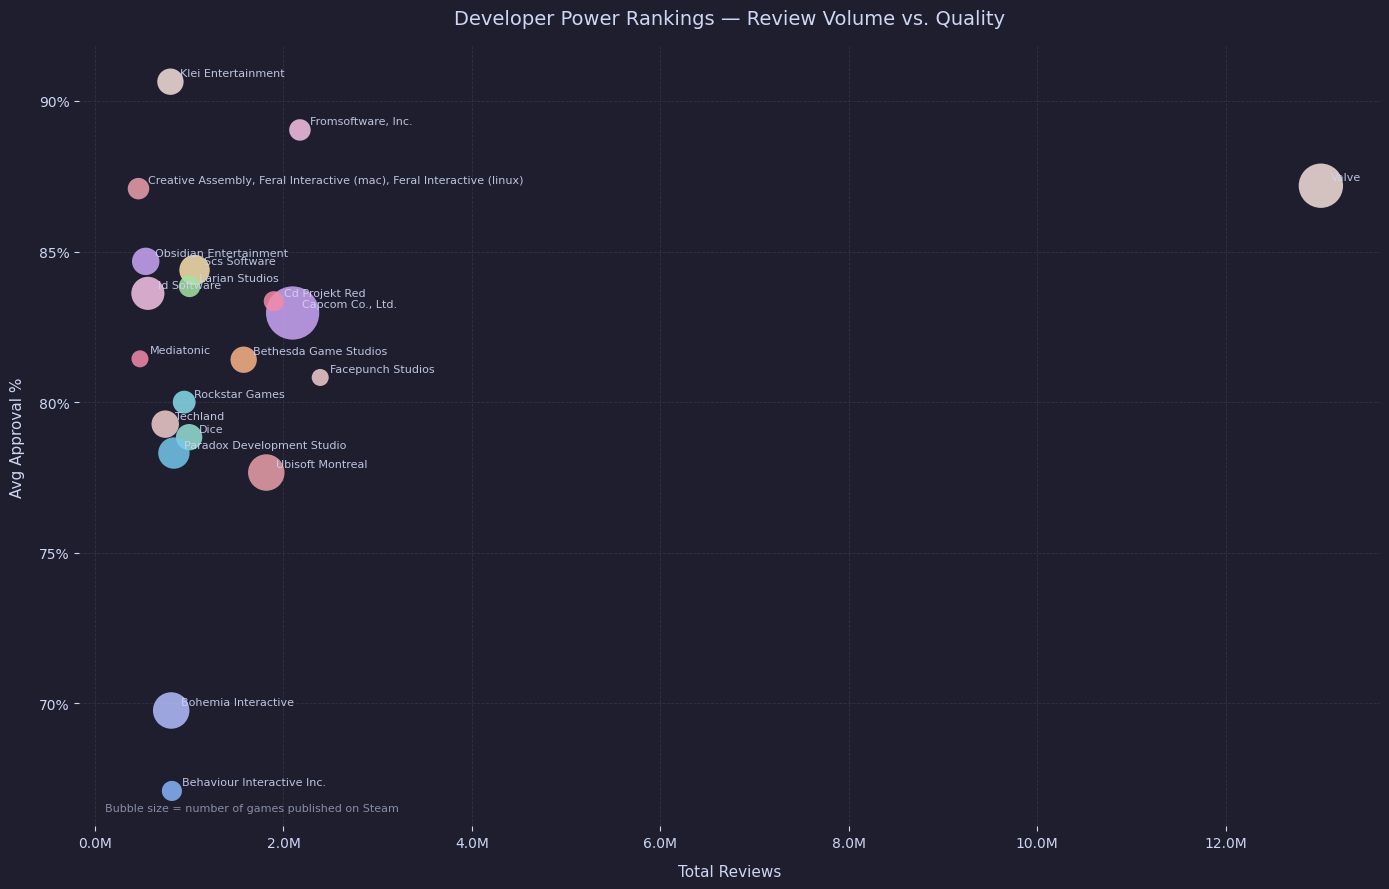

In [8]:
dev_names     = [title_case(r[0]) for r in dev_rows]
num_games     = [r[1] for r in dev_rows]
total_reviews = [r[2] for r in dev_rows]
avg_approval  = [(r[3] * 100) if r[3] is not None else 0 for r in dev_rows]

bubble_sizes  = [max(n * 30, 80) for n in num_games]
bubble_colors = [CATPPUCCIN_MOCHA[i % len(CATPPUCCIN_MOCHA)] for i in range(len(dev_names))]

fig, ax = plt.subplots(figsize=(14, 9), facecolor=CATPPUCCIN_BASE)
style_ax(ax)

ax.scatter(total_reviews, avg_approval,
           s=bubble_sizes, c=bubble_colors,
           alpha=0.85, edgecolors='none')

for i, name in enumerate(dev_names):
    ax.annotate(
        name,
        (total_reviews[i], avg_approval[i]),
        xytext=(7, 4),
        textcoords='offset points',
        color=TEXT_COLOR,
        fontsize=8,
        alpha=0.9,
    )

ax.set_xlabel('Total Reviews', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_ylabel('Avg Approval %', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_title('Developer Power Rankings \u2014 Review Volume vs. Quality',
             color=TEXT_COLOR, fontsize=14, pad=16)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v / 1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

ax.text(0.02, 0.02, 'Bubble size = number of games published on Steam',
        transform=ax.transAxes, color=TEXT_COLOR, fontsize=8, alpha=0.6)

ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')

plt.tight_layout()
plt.savefig('developer_power_rankings.png', dpi=150, bbox_inches='tight', facecolor=CATPPUCCIN_BASE)
plt.show()

**Chart 4 — Developer Power Rankings Scatter**

Every bubble is a studio. X-axis = raw reach (total reviews from all their games). Y-axis = average approval across their catalogue. Bubble size = number of games published.

- **Valve** sits alone in the top-right: the largest total review count of any developer *and* among the highest average approval (~87%). No other studio has both.
- **Klei Entertainment** (Don't Starve, Oxygen Not Included, Invisible Inc.) is the quality outlier: a small bubble, modest total reviews, but among the highest approval on the chart — above 90%. They ship fewer games and nearly all of them land.
- **FromSoftware** (Dark Souls, Elden Ring) has a similar quality-over-volume profile: a small catalogue but very high approval, driven by a passionate audience willing to leave positive reviews even on punishing games.
- **Behaviour Interactive** (Dead by Daylight) and **Bohemia Interactive** (DayZ, ARMA) show high total reviews but approval scores that lag meaningfully behind the cluster — large, divisive communities.
- **Capcom** has the largest bubble in the middle of the chart: 49 games, solid average approval, but spread across many titles means some carry the average up and others drag it down.

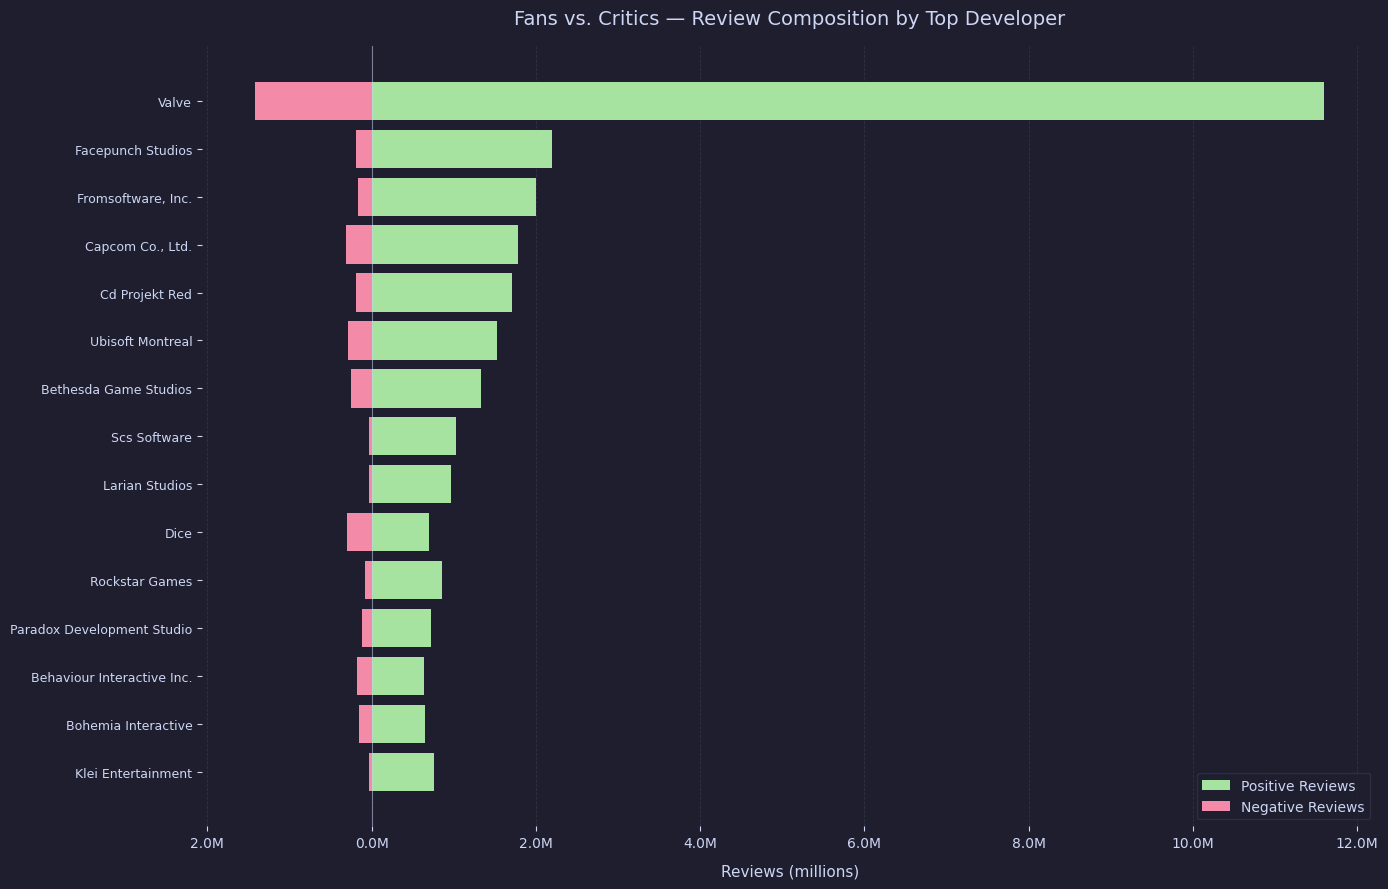

In [9]:
# Top 15 by total reviews, reversed so rank 1 appears at the top of the chart
top15 = list(dev_rows[:15])[::-1]

names     = [title_case(r[0]) for r in top15]
positives = [r[4] / 1e6 for r in top15]
negatives = [r[5] / 1e6 for r in top15]

y = np.arange(len(names))

fig, ax = plt.subplots(figsize=(14, 9), facecolor=CATPPUCCIN_BASE)
style_ax(ax)

ax.barh(y,  positives,              color=C_GREEN, edgecolor='none', label='Positive Reviews')
ax.barh(y, [-n for n in negatives], color=C_RED,   edgecolor='none', label='Negative Reviews')

ax.set_yticks(y)
ax.set_yticklabels(names, color=TEXT_COLOR, fontsize=9)
ax.set_xlabel('Reviews (millions)', color=TEXT_COLOR, fontsize=11, labelpad=10)
ax.set_title('Fans vs. Critics \u2014 Review Composition by Top Developer',
             color=TEXT_COLOR, fontsize=14, pad=16)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{abs(v):.1f}M'))

ax.axvline(0, color=TEXT_COLOR, linewidth=0.8, alpha=0.5)
ax.legend(facecolor=CATPPUCCIN_BASE, labelcolor=TEXT_COLOR,
          framealpha=0.8, edgecolor=GRID_COLOR)
ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.6, linestyle='--')

plt.tight_layout()
plt.savefig('fans_vs_critics.png', dpi=150, bbox_inches='tight', facecolor=CATPPUCCIN_BASE)
plt.show()

**Chart 5 — Fans vs. Critics**

The bubble scatter shows where developers sit on the volume/quality plane. This chart opens each bubble up and shows the *composition* of that sentiment — positive reviews extend right (green), negative extend left (red).

- **Valve's** green bar extends far to the right while the red bar is narrow relative to the total — the highest positive-to-negative ratio of any high-volume studio. The community largely agrees these are good games.
- **CD Projekt Red** (Cyberpunk 2077, The Witcher series) has a large positive bar but a notably thick red bar for its volume. Beloved IP, divisive launches — the Cyberpunk release-day sentiment shows up clearly in the ratio.
- **Behaviour Interactive** (Dead by Daylight) tells the starkest polarisation story: the red bar is nearly as long as the green one. For every fan there is close to a critic. A live-service game with years of balance controversies written in aggregate review data.
- **Klei Entertainment** and **Larian Studios** (Baldur's Gate 3) show thin red bars relative to their green — studios where even players who eventually bounce tend not to leave angry reviews.

The chart pairs with Chart 4: bubbles that sit low on the Y-axis in the scatter will show a thicker red bar here. The relationship is direct.

### Story 2 Summary — Developer Power Rankings

> *The developer landscape on Steam is a classic power law with a twist: Valve sits at the apex, but scale alone does not earn the top-right position on the quality/volume chart. Studios like Klei and FromSoftware demonstrate that a small, curated catalogue can match or exceed the approval ratings of developers with ten times as many games. The studios that accumulate high review volume with mediocre approval scores (Behaviour Interactive, Bohemia Interactive) signal that live-service and early-access models generate engagement without necessarily generating satisfaction. The diverging bar makes the dynamic concrete: the shape of a studio's bar — how balanced the green and red are — is essentially a snapshot of its community's trust. Trust, once earned, compounds across a catalogue; once lost, it haunts every future release.*